# Trabajo Practico 3
## Visión de Computadora I

### Integrantes 
* Lucia T. Capon Paul
* Cesar Orellana
* Madrid, Martin
* Leandro Britez


### Ejercicios : 

Encontrar el logotipo de la gaseosa dentro de las imágenes provistas en `Material_TPs/TP3/`images a partir del template `Material_TPs/TP3/template`

1. Obtener una detección del logo en cada imagen sin falsos positivos

2. Plantear y validar un algoritmo para múltiples detecciones en la imagen coca_multi.png con el mismo témplate del ítem 1.

3. Generalizar el algoritmo del item 2 para todas las imágenes. 

Visualizar los resultados con bounding boxes en cada imagen mostrando el nivel de confianza
de la detección.

---

### Desarrollo 1

In [1]:
from pathlib import Path

import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

IMAGE_DIR = Path("images")
TEMPLATE_PATH = Path("template/pattern.png")

image_names = [
    "COCA-COLA-LOGO.jpg",
    "coca_logo_1.png",
    "coca_logo_2.png",
    "coca_multi.png",
    "coca_retro_1.png",
    "coca_retro_2.png",
    "logo_1.png",
]


In [2]:
def match_template(img_gray, tpl_gray, scales):
    best_det = None
    for s in scales:
        w = int(tpl_gray.shape[1] * s)
        h = int(tpl_gray.shape[0] * s)
        if w < 10 or h < 10 or w > img_gray.shape[1] or h > img_gray.shape[0]:
            continue

        tpl_rs = cv.resize(tpl_gray, (w, h))
        res = cv.matchTemplate(img_gray, tpl_rs, cv.TM_CCOEFF_NORMED)
        _, score, _, loc = cv.minMaxLoc(res)

        if best_det is None or score > best_det[1]:
            best_det = ((loc[0], loc[1], w, h), score)

    return best_det


def match_sift(img_gray, tpl_gray, min_inliers=8):
    sift = cv.SIFT_create()
    kp1, des1 = sift.detectAndCompute(tpl_gray, None)
    kp2, des2 = sift.detectAndCompute(img_gray, None)

    bf = cv.BFMatcher()
    matches = bf.knnMatch(des1, des2, k=2)
    good = [m for m, n in matches if m.distance < 0.75 * n.distance]
    if len(good) < min_inliers:
        return None

    src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    H, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 5.0)
    inliers = int(mask.sum())
    if inliers < min_inliers:
        return None

    h, w = tpl_gray.shape
    corners = np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2)
    proj = cv.perspectiveTransform(corners, H)
    x, y, bw, bh = cv.boundingRect(np.int32(proj))

    return ((x, y, bw, bh), inliers / len(good))


def best(dets):
    # El template es rojo sobre blanco, pero el logo aparece en ambas
    # polaridades segun la imagen. Probamos las dos versiones y nos
    # quedamos con la mejor deteccion (mayor score).
    dets = [d for d in dets if d is not None]
    return max(dets, key=lambda d: d[1]) if dets else None


def draw_box(img, det, color, label):
    out = img.copy()
    if det is None:
        cv.putText(out, f"{label}: sin deteccion", (10, 30),
                   cv.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
        return out

    (x, y, w, h), score = det
    cv.rectangle(out, (x, y), (x + w, y + h), color, 3)
    cv.putText(out, f"{label} conf={score:.2f}", (x, max(20, y - 8)),
               cv.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
    return out


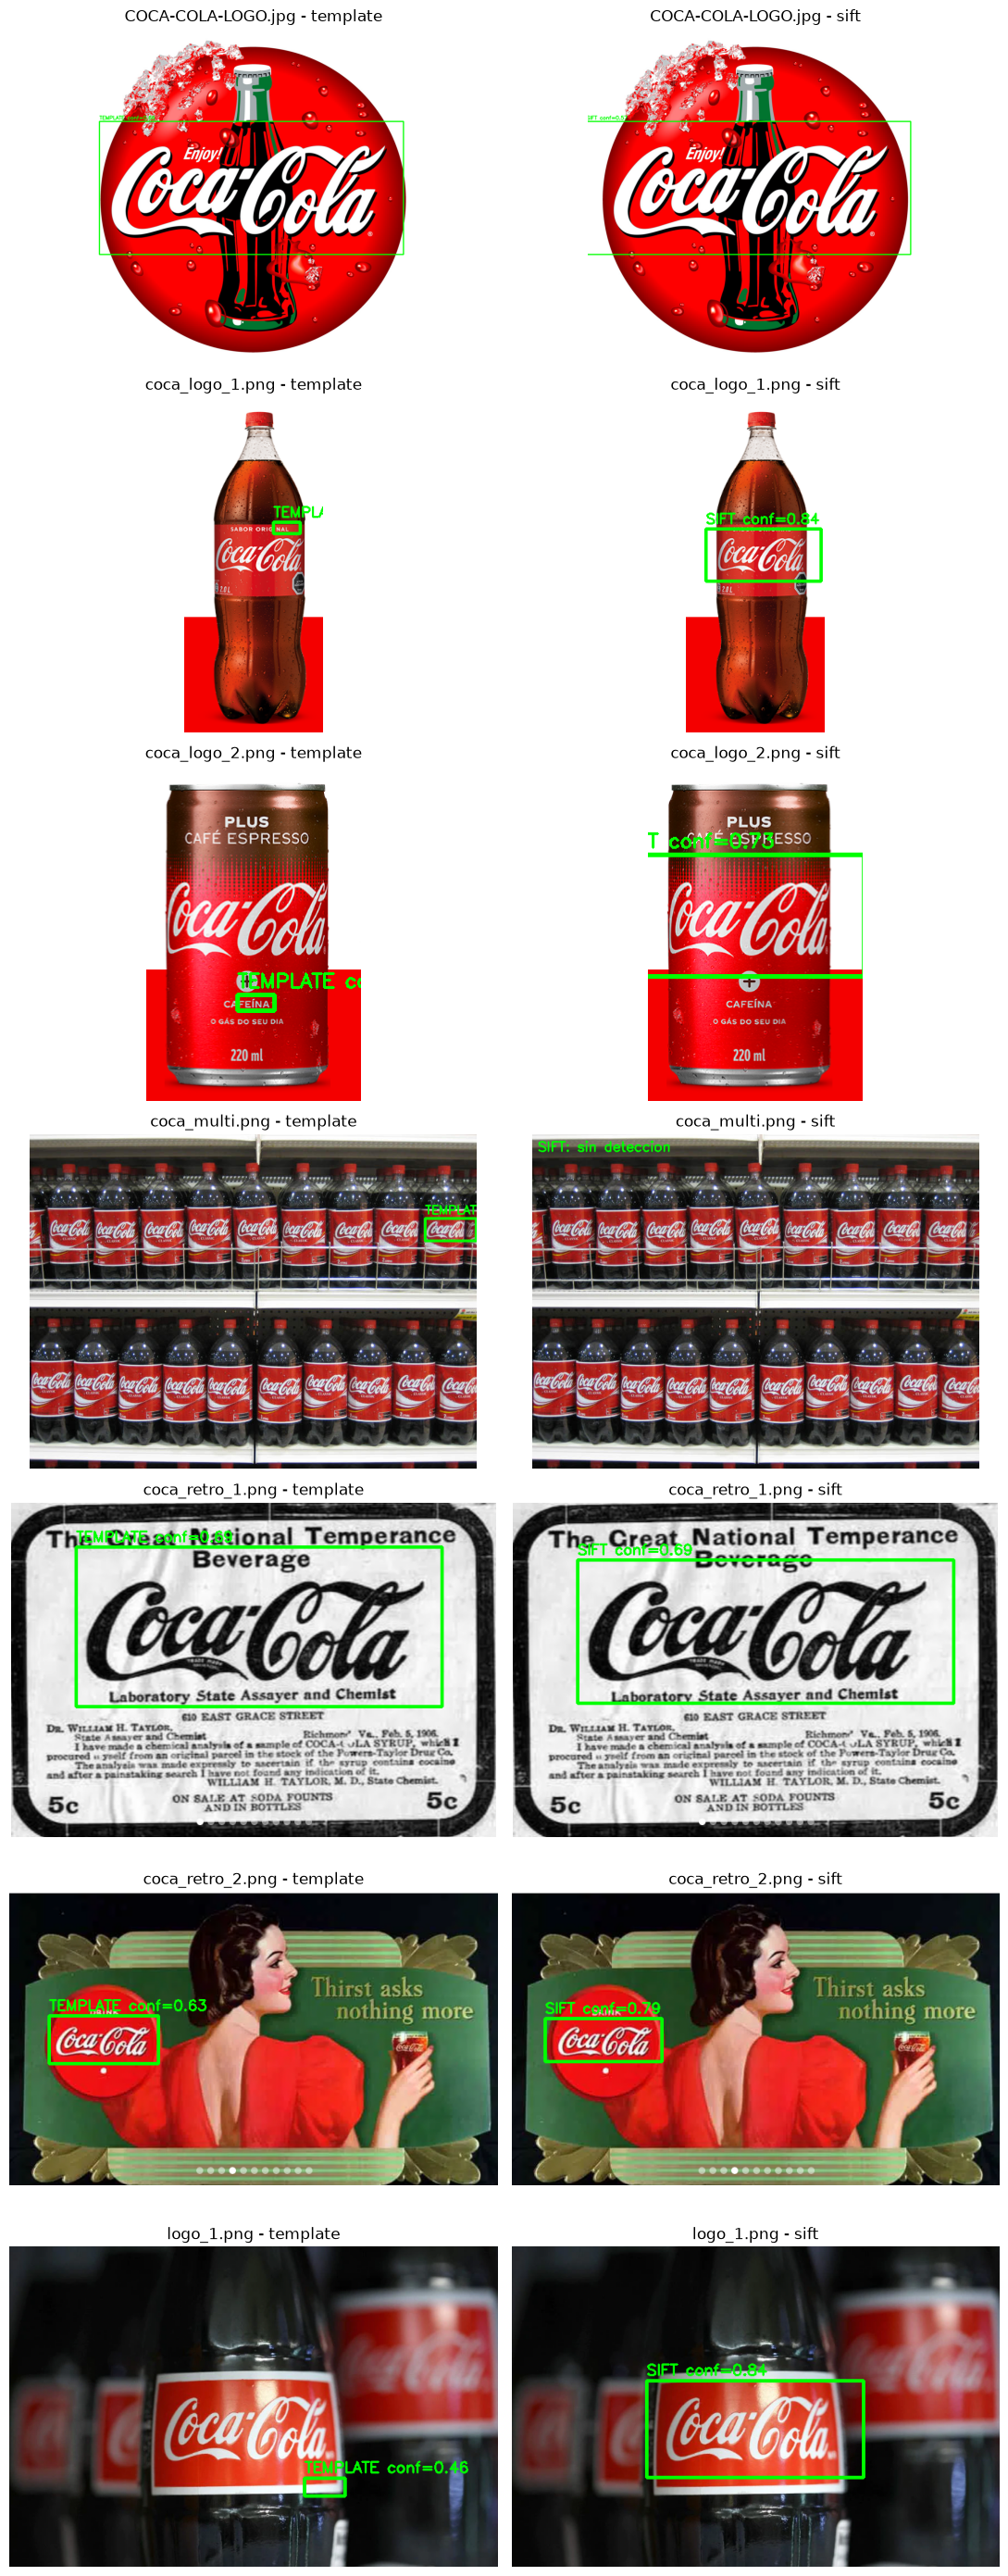

In [3]:
template = cv.imread(str(TEMPLATE_PATH))
tpl_gray = cv.cvtColor(template, cv.COLOR_BGR2GRAY)
tpl_inv = 255 - tpl_gray
scales = np.linspace(0.1, 3.5, 80)

fig, axes = plt.subplots(len(image_names), 2, figsize=(11, 4 * len(image_names)))

for row, name in enumerate(image_names):
    img = cv.imread(str(IMAGE_DIR / name))
    img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    det_tpl = best([match_template(img_gray, tpl_gray, scales),
                    match_template(img_gray, tpl_inv, scales)])
    det_sift = best([match_sift(img_gray, tpl_gray),
                     match_sift(img_gray, tpl_inv)])

    axes[row, 0].imshow(cv.cvtColor(draw_box(img, det_tpl, (0, 255, 0), "TEMPLATE"), cv.COLOR_BGR2RGB))
    axes[row, 0].set_title(f"{name} - template")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(cv.cvtColor(draw_box(img, det_sift, (0, 255, 0), "SIFT"), cv.COLOR_BGR2RGB))
    axes[row, 1].set_title(f"{name} - sift")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()


 ### Conclusiones

* Todas las imágenes fueron procesadas inicialmente en escala de grises, utilizando las versiones en color únicamente para la visualización final de las detecciones mediante bounding boxes.

* El principal inconveniente observado durante los experimentos fue la diferencia de polaridad entre el template y muchas de las imágenes del conjunto de datos. Mientras que el template presenta texto oscuro sobre fondo claro, varios logos aparecen como texto claro sobre fondos oscuros o de alto contraste. Para mitigar este problema, se evaluó tanto el template original como su versión invertida, conservando en cada caso la detección con mayor nivel de confianza.

* Entre los métodos evaluados, SIFT obtuvo el mejor desempeño para detecciones únicas, logrando detectar correctamente 6 de las 7 imágenes analizadas sin generar falsos positivos. Este comportamiento resulta consistente con la teoría, ya que SIFT es invariante a cambios de escala y presenta una mayor robustez frente a deformaciones geométricas, variaciones de perspectiva y cambios moderados de iluminación.

* Por otro lado, Template Matching mostró un desempeño satisfactorio en imágenes donde el logotipo aparece de forma frontal, con buena resolución y sin deformaciones significativas. Un resultado particularmente interesante fue su desempeño sobre la imagen de la góndola de botellas, donde el logo aparece repetido y con tamaño reducido. En este caso, Template Matching superó a SIFT, ya que este último genera correspondencias distribuidas entre múltiples instancias idénticas del logo. Como consecuencia, las coincidencias se reparten entre diferentes botellas y el algoritmo RANSAC no consigue estimar una homografía consistente para una única detección.

* Los resultados obtenidos sugieren que ambos enfoques poseen fortalezas complementarias. SIFT resulta más robusto ante cambios de escala, orientación y perspectiva, mientras que Template Matching puede ofrecer mejores resultados cuando se busca detectar patrones repetitivos o logotipos pequeños cuya apariencia es muy similar al template de referencia.


---